# 06. Entrenamiento de ResNet50 sobre APTOS 2019

Este notebook entrena el primer modelo candidato para la clasificación
de Retinopatía Diabética: ResNet50 preentrenada sobre ImageNet.

El entrenamiento se realiza en dos fases:

1. Transfer Learning con el backbone convolucional congelado.
2. Fine-Tuning parcial de las capas superiores del backbone.

Se utilizan exclusivamente Train y Validation.

El conjunto Test permanece aislado y no participa en el entrenamiento,
ajuste de hiperparámetros ni selección de checkpoints.

Dentro de cada fase, el checkpoint se selecciona utilizando la menor
pérdida de Validation (`val_loss`).

La comparación posterior entre ResNet50 y EfficientNetB3+SE utilizará
como métrica principal Quadratic Weighted Kappa (QWK) y como métrica
secundaria Macro F1.

## 2. Importación de librerías y configuración del entorno

Se importan las dependencias necesarias para la manipulación de datos, el cálculo de métricas de clasificación multiclase y ordinal (QWK), y la construcción del modelo en TensorFlow/Keras.

In [1]:
from pathlib import Path
import json
import gc
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

I0000 00:00:1790752592.076917  251470 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790752592.556744  251470 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790752594.202108  251470 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### 2.1. Definición de rutas del proyecto y persistencia

Se establecen las rutas absolutas para cargar el manifiesto de imágenes preprocesadas, la configuración congelada del pipeline y los directorios de salida para modelos y métricas de ResNet50.

In [2]:
PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)
METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)
MANIFEST_PATH = (
    METADATA_DIR
    / "aptos2019_processed_manifest.csv"
)
PIPELINE_CONFIG_PATH = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "training_pipeline"
    / "aptos2019_training_pipeline_config.json"
)
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "resnet50"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "RD"
    / "resnet50"
)
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

### 2.2. Carga de la configuración congelada del pipeline

Se cargan los parámetros experimentales comunes definidos en el notebook anterior, asegurando la consistencia en el tamaño de imagen, tamaño de lote, semilla aleatoria y ponderación de clases.

In [3]:
with open(
    PIPELINE_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:
    pipeline_config = json.load(f)

IMAGE_SIZE = int(
    pipeline_config["image_size"][0]
)
BATCH_SIZE = int(
    pipeline_config["batch_size"]
)
RANDOM_SEED = int(
    pipeline_config["random_seed"]
)
class_weights = {
    int(class_id): float(weight)
    for class_id, weight
    in pipeline_config[
        "class_weights"
    ].items()
}
NUM_CLASSES = 5

print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("RANDOM_SEED:", RANDOM_SEED)
print("Class weights:", class_weights)

IMAGE_SIZE: 384
BATCH_SIZE: 8
RANDOM_SEED: 42
Class weights: {0: 0.38822593476531425, 1: 2.0677966101694913, 2: 0.7565891472868217, 3: 4.135593220338983, 4: 2.652173913043478}


## 3. Configuración de reproducibilidad y verificación de GPU

Se fija la semilla aleatoria global en TensorFlow y se verifica la disponibilidad del acelerador gráfico (GPU) para el entrenamiento.

In [4]:
tf.keras.utils.set_random_seed(
    RANDOM_SEED
)
gpus = tf.config.list_physical_devices(
    "GPU"
)
print(
    "GPUs detectadas:",
    gpus
)

GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790752596.695991  251470 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 4. Carga de particiones de Train y Validation

Se lee el manifiesto de imágenes preprocesadas y se reconstruyen las rutas absolutas. Se filtran únicamente los conjuntos Train y Validation; el conjunto Test se mantiene completamente aislado.

In [5]:
manifest_df = pd.read_csv(
    MANIFEST_PATH
)
manifest_df[
    "absolute_processed_path"
] = (
    manifest_df[
        "processed_path"
    ]
    .apply(
        lambda x:
            str(
                APTOS_ROOT
                / x
            )
    )
)

train_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)
validation_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Train:",
    len(train_df)
)
print(
    "Validation:",
    len(validation_df)
)

Train: 2440
Validation: 523


## 5. Pipeline de datos con `tf.data`

Reutilizamos las especificaciones comunes del pipeline de entrenamiento: decodificación PNG a RGB `float32` conservando el rango [0, 255] a resolución 384 × 384 píxeles.

In [6]:
def load_image_and_label(
    image_path,
    label
):
    image = tf.io.read_file(
        image_path
    )
    image = tf.image.decode_png(
        image,
        channels=3
    )
    image = tf.cast(
        image,
        tf.float32
    )
    image.set_shape(
        [
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ]
    )
    return (
        image,
        tf.cast(
            label,
            tf.int32
        )
    )

### 5.1. Construcción de los datasets de Train y Validation

Se configuran los flujos de datos optimizados con barajado dinámico en entrenamiento, mapeo de lectura y prefetching en GPU.

In [7]:
def build_dataset(
    dataframe,
    training=False
):
    paths = dataframe[
        "absolute_processed_path"
    ].to_numpy()
    labels = dataframe[
        "diagnosis"
    ].to_numpy(
        dtype=np.int32
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                paths,
                labels
            )
        )
    )

    if training:
        dataset = dataset.shuffle(
            len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image_and_label,
        num_parallel_calls=2
    )
    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )
    dataset = dataset.prefetch(
        1
    )

    return dataset


train_ds = build_dataset(
    train_df,
    training=True
)
validation_ds = build_dataset(
    validation_df,
    training=False
)

W0000 00:00:1790752596.769356  251470 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790752597.042325  251470 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


## 6. Definición del módulo de Data Augmentation

Se define la política común de aumentación de datos (volteo horizontal, rotaciones leves, zoom y contraste moderados) para ser ejecutada directamente dentro del modelo únicamente en modo de entrenamiento (`training=True`).

In [8]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal",
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomRotation(
            factor=0.03,
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            width_factor=(-0.10, 0.10),
            fill_mode="constant",
            fill_value=0.0,
            seed=RANDOM_SEED
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10,
            seed=RANDOM_SEED
        )
    ],
    name="rd_data_augmentation"
)

## 7. Arquitectura ResNet50

Se utiliza ResNet50 preentrenada sobre ImageNet como extractor de
características.

Durante la primera fase de Transfer Learning, todas las capas del
backbone permanecen congeladas.

Sobre el backbone se incorpora:

- Global Average Pooling;
- Dropout de 0.30;
- capa Dense de 5 unidades;
- activación Softmax.

In [9]:
tf.keras.backend.clear_session()
gc.collect()

base_model = (
    tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        )
    )
)
base_model.trainable = False

### 7.1. Ensamblaje del modelo funcional

Se conectan la capa de aumento de datos, la función de preprocesamiento de ResNet50 (`preprocess_input`), el backbone congelado (`training=False`) y la cabeza clasificadora multiclase.

In [10]:
inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    ),
    name="image"
)
x = data_augmentation(
    inputs
)
x = tf.keras.applications.resnet50.preprocess_input(
    x
)
x = base_model(
    x,
    training=False
)
x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)
x = tf.keras.layers.Dropout(
    0.30,
    name="dropout"
)(x)
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32",
    name="rd_classification"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="resnet50_aptos2019"
)

### 7.2. Resumen de la arquitectura del modelo

Se genera el resumen tabular de la arquitectura para inspeccionar la secuencia de capas y dimensiones intermedias.

In [11]:
model.summary()

Model: "resnet50_aptos2019"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 384, 384,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rd_data_augmentati… │ (None, 384, 384,  │          0 │ image[0][0]       │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 384, 384)  │          0 │ rd_data_augmenta… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 384, 384)  │          0 │ rd_data_augmenta… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 384, 384)  │          0 │ rd_data_augmenta… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 384, 384,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 384, 384,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 12, 12,    │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rd_classification   │ (None, 5)         │     10,245 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### 7.3. Verificación y discriminación de parámetros

Se realiza el conteo formal de los parámetros totales, entrenables y no entrenables, asegurando que únicamente los pesos de la cabecera densa sean actualizables durante la fase de Transfer Learning inicial.

In [12]:
total_params = model.count_params()
trainable_params = sum(
    np.prod(v.shape)
    for v in model.trainable_weights
)
non_trainable_params = (
    total_params
    - trainable_params
)

print(
    "Parámetros totales:",
    f"{total_params:,}"
)
print(
    "Parámetros entrenables:",
    f"{trainable_params:,}"
)
print(
    "Parámetros no entrenables:",
    f"{non_trainable_params:,}"
)

Parámetros totales: 23,597,957
Parámetros entrenables: 10,245
Parámetros no entrenables: 23,587,712


## 8. Fase 1: Transfer Learning

Durante esta primera fase, el backbone ResNet50 preentrenado sobre
ImageNet permanece completamente congelado.

Únicamente se entrena la cabeza de clasificación incorporada para las
cinco categorías de Retinopatía Diabética.

Se utiliza Sparse Categorical Crossentropy como función de pérdida,
Adam como optimizador y los pesos de clase calculados exclusivamente
sobre Train.

El mejor checkpoint de esta fase se selecciona mediante la menor
pérdida observada sobre Validation (`val_loss`).

### 8.1. Compilación del modelo

Se configura el optimizador Adam con una tasa de aprendizaje inicial de 1e-3, la función de pérdida Sparse Categorical Crossentropy y la métrica de exactitud categórica dispersa. Las métricas globales como QWK y Macro F1 se calculan posteriormente sobre la totalidad de Validation para evitar distorsiones por promedios batch a batch.

In [13]:
TRANSFER_LR = 1e-3
TRANSFER_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 4

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=TRANSFER_LR
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "Learning rate:",
    TRANSFER_LR
)
print(
    "Máximo de epochs:",
    TRANSFER_EPOCHS
)

Learning rate: 0.001
Máximo de epochs: 15


### 8.2. Callbacks de entrenamiento y persistencia

Se configuran `ModelCheckpoint` para monitorear `val_loss` y salvar el mejor modelo en formato Keras nativo, `EarlyStopping` con paciencia de 4 épocas restaurando los mejores pesos, y `CSVLogger` para el seguimiento del entrenamiento.

In [14]:
TRANSFER_MODEL_PATH = (
    MODEL_DIR
    / "resnet50_transfer_best.keras"
)
TRANSFER_LOG_PATH = (
    RESULTS_DIR
    / "resnet50_transfer_log.csv"
)

transfer_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=TRANSFER_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        TRANSFER_LOG_PATH,
        append=False
    )
]

print(
    "Checkpoint:",
    TRANSFER_MODEL_PATH
)
print(
    "Log:",
    TRANSFER_LOG_PATH
)

Checkpoint: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_transfer_best.keras
Log: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/resnet50/resnet50_transfer_log.csv


### 8.3. Ejecución del entrenamiento de Transfer Learning

Se ajusta el modelo sobre `train_ds` con validación en `validation_ds`, aplicando la ponderación de clases calculada sobre Train (`class_weights`).

In [15]:
transfer_start = time.time()

transfer_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=TRANSFER_EPOCHS,
    class_weight=class_weights,
    callbacks=transfer_callbacks,
    verbose=1
)

transfer_end = time.time()
transfer_minutes = (
    transfer_end
    - transfer_start
) / 60

print(
    f"Tiempo Transfer Learning: "
    f"{transfer_minutes:.2f} minutos"
)

Epoch 1/15


/home/seung720/.venvs/retiscan/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790752604.472336  251577 cuda_dnn.cc:461] Loaded cuDNN version 92600


304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5855 - loss: 1.3562
Epoch 1: val_loss improved from None to 0.75415, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_transfer_best.keras

Epoch 1: finished saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_transfer_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.5861 - loss: 1.3565 - val_accuracy: 0.6711 - val_loss: 0.7542
Epoch 2/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6844 - loss: 1.1254
Epoch 2: val_loss improved from 0.75415 to 0.63741, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_transfer_best.keras

Epoch 2: finished saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_transfer_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.6844 - loss: 1.1254 - val_accuracy: 0.7648 - val_loss: 0.6374
Epoch 3/15
305/305 ━━━━━

### 8.4. Identificación del mejor epoch

Se inspecciona el log de entrenamiento para determinar la época exacta en la que se obtuvo el mínimo valor de `val_loss` y reportar la exactitud asociada.

In [16]:
transfer_log_df = pd.read_csv(
    TRANSFER_LOG_PATH
)
best_transfer_idx = (
    transfer_log_df[
        "val_loss"
    ].idxmin()
)
best_transfer_row = (
    transfer_log_df
    .loc[
        best_transfer_idx
    ]
)
best_transfer_epoch = (
    int(
        best_transfer_row[
            "epoch"
        ]
    )
    + 1
)

print(
    "Mejor epoch Transfer:",
    best_transfer_epoch
)
print(
    "val_loss:",
    f"{best_transfer_row['val_loss']:.6f}"
)
print(
    "val_accuracy:",
    f"{best_transfer_row['val_accuracy']:.6f}"
)

Mejor epoch Transfer: 2
val_loss: 0.637407
val_accuracy: 0.764818


### 8.5. Curvas de entrenamiento

Se exporta el historial completo de entrenamiento a formato CSV y se grafican las curvas de pérdida para Train y Validation.

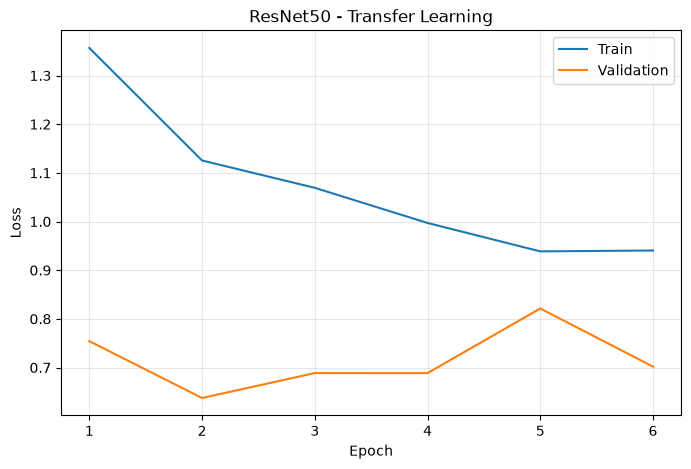

In [17]:
history_df = pd.DataFrame(
    transfer_history.history
)
history_df[
    "epoch"
] = np.arange(
    1,
    len(history_df) + 1
)
history_df.to_csv(
    RESULTS_DIR
    / "resnet50_transfer_history.csv",
    index=False
)

plt.figure(
    figsize=(8, 5)
)
plt.plot(
    history_df["epoch"],
    history_df["loss"],
    label="Train"
)
plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "ResNet50 - Transfer Learning"
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Recuperación del entorno después de reinicio del kernel

Se reconstruyen las variables, rutas y datasets necesarios para continuar
la evaluación del checkpoint de Transfer Learning previamente guardado.
No se repite el entrenamiento.

In [1]:
from pathlib import Path
import json
import gc
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)

APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)

METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)

MANIFEST_PATH = (
    METADATA_DIR
    / "aptos2019_processed_manifest.csv"
)

PIPELINE_CONFIG_PATH = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "training_pipeline"
    / "aptos2019_training_pipeline_config.json"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "resnet50"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "RD"
    / "resnet50"
)

TRANSFER_MODEL_PATH = (
    MODEL_DIR
    / "resnet50_transfer_best.keras"
)

TRANSFER_LOG_PATH = (
    RESULTS_DIR
    / "resnet50_transfer_log.csv"
)

with open(
    PIPELINE_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:
    pipeline_config = json.load(f)

IMAGE_SIZE = int(
    pipeline_config["image_size"][0]
)

BATCH_SIZE = int(
    pipeline_config["batch_size"]
)

RANDOM_SEED = int(
    pipeline_config["random_seed"]
)

NUM_CLASSES = 5

class_weights = {
    int(k): float(v)
    for k, v in pipeline_config[
        "class_weights"
    ].items()
}

tf.keras.utils.set_random_seed(
    RANDOM_SEED
)

print("Checkpoint existe:", TRANSFER_MODEL_PATH.exists())
print("IMAGE_SIZE:", IMAGE_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)

I0000 00:00:1790753537.355176  254455 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790753537.613162  254455 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790753539.464562  254455 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Checkpoint existe: True
IMAGE_SIZE: 384
BATCH_SIZE: 8


In [4]:
manifest_df = pd.read_csv(
    MANIFEST_PATH
)

manifest_df[
    "absolute_processed_path"
] = manifest_df[
    "processed_path"
].apply(
    lambda x:
        str(APTOS_ROOT / x)
)

validation_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Validation:",
    len(validation_df)
)

Validation: 523


In [5]:
def load_image_and_label(
    image_path,
    label
):
    image = tf.io.read_file(
        image_path
    )

    image = tf.image.decode_png(
        image,
        channels=3
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image.set_shape(
        [
            IMAGE_SIZE,
            IMAGE_SIZE,
            3
        ]
    )

    label = tf.cast(
        label,
        tf.int32
    )

    return image, label


def build_dataset(
    dataframe,
    training=False
):
    paths = dataframe[
        "absolute_processed_path"
    ].to_numpy()

    labels = dataframe[
        "diagnosis"
    ].to_numpy(
        dtype=np.int32
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            paths,
            labels
        )
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image_and_label,
        num_parallel_calls=2
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    dataset = dataset.prefetch(1)

    return dataset

In [6]:
validation_ds = build_dataset(
    validation_df,
    training=False
)

print(
    "Validation dataset reconstruido."
)

Validation dataset reconstruido.


## 9. Evaluación de Transfer Learning sobre Validation

Se evalúa el mejor checkpoint obtenido durante la fase de Transfer
Learning utilizando exclusivamente el conjunto Validation.

Las predicciones se calculan sobre las 523 imágenes sin Data Augmentation.

Además de Accuracy, se calculan las métricas predefinidas para la
comparación experimental:

- Quadratic Weighted Kappa (QWK);
- Macro F1-Score;
- Macro Precision;
- Macro Recall;
- matriz de confusión.

Estas métricas representan el rendimiento de la fase de Transfer Learning
antes de realizar Fine-Tuning.

### 9.1. Carga explícita del mejor checkpoint de Transfer Learning

Se recarga el modelo persistido en disco (`resnet50_transfer_best.keras`) sin compilar para garantizar la evaluación exacta de los pesos óptimos registrados durante la primera fase.

In [7]:
transfer_model = tf.keras.models.load_model(
    TRANSFER_MODEL_PATH,
    compile=False
)

print(
    "Modelo Transfer Learning recuperado."
)

Modelo Transfer Learning recuperado.


### 9.2. Inferencia y alineación de probabilidades sobre Validation

Se obtienen las distribuciones de probabilidad de salida para las 523 muestras de validación y se extraen las etiquetas ground truth correspondientes para cotejo directo.

In [8]:
transfer_probabilities = (
    transfer_model.predict(
        validation_ds,
        verbose=1
    )
)
print(
    "Shape probabilidades:",
    transfer_probabilities.shape
)
print(
    "Suma primera predicción:",
    transfer_probabilities[0].sum()
)

I0000 00:00:1790754191.749646  255951 cuda_dnn.cc:461] Loaded cuDNN version 92600


66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step
Shape probabilidades: (523, 5)
Suma primera predicción: 1.0


### 9.2.1. Extracción de etiquetas reales y clases predichas

Se alinean las etiquetas reales del dataset con la clase predicha de mayor probabilidad (`argmax`) a lo largo del conjunto de validación.

In [9]:
y_val = np.concatenate(
    [
        labels.numpy()
        for _, labels
        in validation_ds
    ]
)
y_pred_transfer = np.argmax(
    transfer_probabilities,
    axis=1
)
print(
    "Labels reales:",
    y_val.shape
)
print(
    "Predicciones:",
    y_pred_transfer.shape
)
print(
    "Clases predichas:",
    sorted(
        np.unique(
            y_pred_transfer
        ).tolist()
    )
)

Labels reales: (523,)
Predicciones: (523,)
Clases predichas: [0, 1, 2, 3, 4]


### 9.3. Cálculo de métricas globales de Transfer Learning

Se calculan las métricas oficiales: QWK con ponderación cuadrática, Macro F1, Accuracy, Macro Precision, Macro Recall y la matriz de confusión multiclase sobre las 523 imágenes de validación.

In [10]:
transfer_qwk = cohen_kappa_score(
    y_val,
    y_pred_transfer,
    weights="quadratic"
)
transfer_macro_f1 = f1_score(
    y_val,
    y_pred_transfer,
    average="macro",
    zero_division=0
)
transfer_accuracy = accuracy_score(
    y_val,
    y_pred_transfer
)
transfer_macro_precision = precision_score(
    y_val,
    y_pred_transfer,
    average="macro",
    zero_division=0
)
transfer_macro_recall = recall_score(
    y_val,
    y_pred_transfer,
    average="macro",
    zero_division=0
)
transfer_cm = confusion_matrix(
    y_val,
    y_pred_transfer,
    labels=[
        0, 1, 2, 3, 4
    ]
)

print(
    f"QWK:             "
    f"{transfer_qwk:.6f}"
)
print(
    f"Macro F1:        "
    f"{transfer_macro_f1:.6f}"
)
print(
    f"Accuracy:        "
    f"{transfer_accuracy:.6f}"
)
print(
    f"Macro Precision: "
    f"{transfer_macro_precision:.6f}"
)
print(
    f"Macro Recall:    "
    f"{transfer_macro_recall:.6f}"
)
print(
    "\nMatriz de confusión:"
)
print(
    transfer_cm
)

QWK:             0.821466
Macro F1:        0.537860
Accuracy:        0.764818
Macro Precision: 0.609298
Macro Recall:    0.550948

Matriz de confusión:
[[255   4   9   0   1]
 [  4  13  27   0   7]
 [  3   2 101   3  29]
 [  0   0  16   3   6]
 [  0   0  10   2  28]]


### 9.4. Evaluación detallada por clase

Se genera el reporte de clasificación discriminando precisión, recall y F1-score para cada uno de los 5 grados de severidad, prestando especial atención al comportamiento en las clases minoritarias (Leve, Severa y Proliferativa).

In [11]:
from sklearn.metrics import classification_report

transfer_report = classification_report(
    y_val,
    y_pred_transfer,
    labels=[
        0, 1, 2, 3, 4
    ],
    target_names=[
        "Sin RD",
        "Leve",
        "Moderada",
        "Severa",
        "Proliferativa"
    ],
    output_dict=True,
    zero_division=0
)
transfer_report_df = (
    pd.DataFrame(
        transfer_report
    )
    .transpose()
)
display(
    transfer_report_df.round(4)
)

,precision,recall,f1-score,support
Sin RD,0.9733,0.9480,0.9605,269.0000
Leve,0.6842,0.2549,0.3714,51.0000
Moderada,0.6196,0.7319,0.6711,138.0000
Severa,0.3750,0.1200,0.1818,25.0000
Proliferativa,0.3944,0.7000,0.5045,40.0000
accuracy,0.7648,0.7648,0.7648,0.7648
macro avg,0.6093,0.5509,0.5379,523.0000
weighted avg,0.7789,0.7648,0.7546,523.0000


### 9.5. Persistencia de predicciones de Validation

Se guardan las probabilidades por clase y la predicción final de cada imagen de Validation en formato CSV para la posterior comparación directa en el notebook 08.

In [12]:
transfer_validation_results = (
    validation_df[
        [
            "id_code",
            "diagnosis"
        ]
    ]
    .copy()
)
transfer_validation_results[
    "predicted_class"
] = y_pred_transfer

for class_id in range(
    NUM_CLASSES
):
    transfer_validation_results[
        f"score_class_{class_id}"
    ] = (
        transfer_probabilities[
            :,
            class_id
        ]
    )

TRANSFER_VALIDATION_PATH = (
    RESULTS_DIR
    / "resnet50_transfer_validation_predictions.csv"
)
transfer_validation_results.to_csv(
    TRANSFER_VALIDATION_PATH,
    index=False
)

### 9.5.1. Resumen tabular de métricas de Transfer Learning

Se estructura y persiste el resumen de métricas globales de la fase de Transfer Learning en disco.

In [13]:
transfer_metrics_df = pd.DataFrame(
    {
        "metric": [
            "QWK",
            "Macro F1",
            "Accuracy",
            "Macro Precision",
            "Macro Recall"
        ],
        "value": [
            transfer_qwk,
            transfer_macro_f1,
            transfer_accuracy,
            transfer_macro_precision,
            transfer_macro_recall
        ]
    }
)
display(
    transfer_metrics_df.round(6)
)
transfer_metrics_df.to_csv(
    RESULTS_DIR
    / "resnet50_transfer_metrics.csv",
    index=False
)

,metric,value
0,QWK,0.821466
1,Macro F1,0.537860
2,Accuracy,0.764818
3,Macro Precision,0.609298
4,Macro Recall,0.550948


## 10. Fase 2: Fine-Tuning parcial

Después de la fase inicial de Transfer Learning, se realiza Fine-Tuning
parcial sobre el último bloque convolucional de ResNet50 (`conv5_x`).

Las capas anteriores permanecen congeladas con el objetivo de conservar
las representaciones generales aprendidas sobre ImageNet y limitar el
riesgo de sobreajuste.

Las capas Batch Normalization se mantienen congeladas durante esta fase.

Se utiliza una tasa de aprendizaje reducida de `1e-5` para realizar
ajustes graduales sobre las características de alto nivel.

El mejor checkpoint se selecciona nuevamente mediante la menor pérdida
sobre Validation (`val_loss`).

### 10.1. Identificación y descongelamiento selectivo del backbone

Se localiza el extractor convolucional ResNet50 dentro del grafo y se descongelan únicamente las capas del bloque final `conv5_x`, preservando congeladas todas las capas de `BatchNormalization` para evitar desestabilizar los estadísticos aprendidos.

In [14]:
base_model = transfer_model.get_layer(
    "resnet50"
)
print(
    "Backbone:",
    base_model.name
)
print(
    "Capas del backbone:",
    len(base_model.layers)
)

Backbone: resnet50
Capas del backbone: 175


### 10.1.1. Descongelamiento de `conv5_x` y congelamiento de `BatchNormalization`

Se itera sobre las capas del backbone activando `trainable = True` exclusivamente para aquellas con prefijo `conv5_`, forzando `trainable = False` en cualquier capa de normalización por lotes.

In [15]:
base_model.trainable = True
for layer in base_model.layers:
    if layer.name.startswith(
        "conv5_"
    ):
        layer.trainable = True
    else:
        layer.trainable = False
    # Batch Normalization siempre congelada
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

### 10.1.2. Inspección de capas activas del backbone

Se verifican los nombres de las capas entrenables para corroborar que pertenezcan unívocamente al bloque semántico `conv5_x`.

In [16]:
trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]
print(
    "Capas entrenables del backbone:",
    len(trainable_backbone_layers)
)
print(
    "\nPrimeras capas entrenables:"
)
print(
    trainable_backbone_layers[:10]
)
print(
    "\nÚltimas capas entrenables:"
)
print(
    trainable_backbone_layers[-10:]
)

Capas entrenables del backbone: 22

Primeras capas entrenables:
['conv5_block1_1_conv', 'conv5_block1_1_relu', 'conv5_block1_2_conv', 'conv5_block1_2_relu', 'conv5_block1_0_conv', 'conv5_block1_3_conv', 'conv5_block1_add', 'conv5_block1_out', 'conv5_block2_1_conv', 'conv5_block2_1_relu']

Últimas capas entrenables:
['conv5_block2_3_conv', 'conv5_block2_add', 'conv5_block2_out', 'conv5_block3_1_conv', 'conv5_block3_1_relu', 'conv5_block3_2_conv', 'conv5_block3_2_relu', 'conv5_block3_3_conv', 'conv5_block3_add', 'conv5_block3_out']


### 10.2. Verificación de parámetros entrenables para Fine-Tuning

Se realiza el recuento de parámetros del modelo global (`transfer_model`), confirmando el incremento en los parámetros entrenables correspondientes al bloque `conv5_x` más la cabeza clasificadora.

In [17]:
total_params_ft = (
    transfer_model.count_params()
)
trainable_params_ft = sum(
    np.prod(v.shape)
    for v in transfer_model.trainable_weights
)
non_trainable_params_ft = (
    total_params_ft
    - trainable_params_ft
)

print(
    "Parámetros totales:",
    f"{total_params_ft:,}"
)
print(
    "Parámetros entrenables:",
    f"{trainable_params_ft:,}"
)
print(
    "Parámetros no entrenables:",
    f"{non_trainable_params_ft:,}"
)

Parámetros totales: 23,597,957
Parámetros entrenables: 14,963,717
Parámetros no entrenables: 8,634,240


### 10.3. Recompilación con tasa de aprendizaje reducida

Se recompila el modelo con el optimizador Adam a una tasa reducida de `1e-5`, limitando el entrenamiento a un máximo de 15 épocas con parada temprana por `val_loss`.

In [18]:
FINETUNE_LR = 1e-5
FINETUNE_EPOCHS = 15
FINETUNE_PATIENCE = 4

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINETUNE_LR
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "Learning rate Fine-Tuning:",
    FINETUNE_LR
)
print(
    "Máximo de epochs:",
    FINETUNE_EPOCHS
)

Learning rate Fine-Tuning: 1e-05
Máximo de epochs: 15


### 10.4. Callbacks de Fine-Tuning

Se configuran `ModelCheckpoint` para persistir `resnet50_finetune_best.keras`, `EarlyStopping` con paciencia de 4 épocas y `CSVLogger` para registrar la evolución de esta segunda etapa.

In [19]:
FINETUNE_MODEL_PATH = (
    MODEL_DIR
    / "resnet50_finetune_best.keras"
)
FINETUNE_LOG_PATH = (
    RESULTS_DIR
    / "resnet50_finetune_log.csv"
)

finetune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=FINETUNE_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FINETUNE_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        FINETUNE_LOG_PATH,
        append=False
    )
]

print(
    "Checkpoint Fine-Tuning:",
    FINETUNE_MODEL_PATH
)

Checkpoint Fine-Tuning: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_finetune_best.keras


### 10.5. Reconstrucción de los datasets de entrenamiento y validación

Se asegura la disponibilidad y correcta instanciación de `train_ds` y `validation_ds` antes de lanzar el ciclo de entrenamiento.

In [20]:
train_df = (
    manifest_df[
        manifest_df[
            "experimental_split"
        ] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)
train_ds = build_dataset(
    train_df,
    training=True
)

print(
    "Train reconstruido:",
    len(train_df)
)
print(
    "Validation:",
    len(validation_df)
)

Train reconstruido: 2440
Validation: 523


### 10.6. Ejecución del entrenamiento de Fine-Tuning

Se realiza el ajuste fino sobre `train_ds` con validación en `validation_ds` y ponderación de clases `class_weights`, cronometrando la duración de la etapa.

In [21]:
finetune_start = time.time()

finetune_history = transfer_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=FINETUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=finetune_callbacks,
    verbose=1
)

finetune_end = time.time()
finetune_minutes = (
    finetune_end
    - finetune_start
) / 60

print(
    f"Tiempo Fine-Tuning: "
    f"{finetune_minutes:.2f} minutos"
)

Epoch 1/15


/home/seung720/.venvs/retiscan/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7148 - loss: 0.9407
Epoch 1: val_loss improved from None to 0.57804, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_finetune_best.keras

Epoch 1: finished saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_finetune_best.keras
305/305 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step - accuracy: 0.7148 - loss: 0.9407 - val_accuracy: 0.7725 - val_loss: 0.5780
Epoch 2/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7492 - loss: 0.8402
Epoch 2: val_loss did not improve from 0.57804
305/305 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.7492 - loss: 0.8402 - val_accuracy: 0.7648 - val_loss: 0.6018
Epoch 3/15
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7828 - loss: 0.7509
Epoch 3: val_loss did not improve from 0.57804
305/305 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.7828 - loss: 0.7509 - val_accuracy: 0.7400 - val_loss: 0.6650
Epoch 4/15
30

### 10.7. Identificación del mejor epoch de Fine-Tuning

Se lee el archivo de registro `resnet50_finetune_log.csv` para reportar el epoch que alcanzó el mínimo `val_loss` y la exactitud obtenida.

In [22]:
finetune_log_df = pd.read_csv(
    FINETUNE_LOG_PATH
)
best_finetune_idx = (
    finetune_log_df[
        "val_loss"
    ].idxmin()
)
best_finetune_row = (
    finetune_log_df.loc[
        best_finetune_idx
    ]
)
best_finetune_epoch = (
    int(
        best_finetune_row["epoch"]
    )
    + 1
)

print(
    "Mejor epoch Fine-Tuning:",
    best_finetune_epoch
)
print(
    "val_loss:",
    f"{best_finetune_row['val_loss']:.6f}"
)
print(
    "val_accuracy:",
    f"{best_finetune_row['val_accuracy']:.6f}"
)

Mejor epoch Fine-Tuning: 7
val_loss: 0.544633
val_accuracy: 0.793499


## 11. Evaluación del mejor checkpoint de Fine-Tuning sobre Validation

Se evalúa el mejor checkpoint obtenido durante Fine-Tuning utilizando
las mismas 523 imágenes de Validation empleadas en la evaluación de
Transfer Learning.

Las métricas se calculan exactamente sobre el conjunto completo:

- Quadratic Weighted Kappa (QWK);
- Macro F1-Score;
- Accuracy;
- Macro Precision;
- Macro Recall;
- matriz de confusión;
- rendimiento individual por clase.

Esto permite cuantificar el efecto real del Fine-Tuning sobre ResNet50.

### 11.1. Carga explícita del mejor checkpoint de Fine-Tuning

Se carga desde disco el modelo óptimo persistido por `ModelCheckpoint` durante la segunda fase (`resnet50_finetune_best.keras`).

In [23]:
finetune_model = tf.keras.models.load_model(
    FINETUNE_MODEL_PATH,
    compile=False
)
print(
    "Checkpoint Fine-Tuning cargado:",
    FINETUNE_MODEL_PATH
)

Checkpoint Fine-Tuning cargado: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/RD/resnet50/resnet50_finetune_best.keras


### 11.2. Inferencia y probabilidades sobre Validation

Se ejecutan las predicciones sobre las 523 imágenes de `validation_ds` y se verifica la dimensionalidad y suma unitaria de las probabilidades por muestra.

In [24]:
finetune_probabilities = (
    finetune_model.predict(
        validation_ds,
        verbose=1
    )
)
print(
    "Shape probabilidades:",
    finetune_probabilities.shape
)
print(
    "Suma primera predicción:",
    finetune_probabilities[0].sum()
)

66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step
Shape probabilidades: (523, 5)
Suma primera predicción: 1.0000001


### 11.2.1. Extracción de predicciones discretas de Fine-Tuning

Se obtienen las clases predichas vía `argmax` y se revalida la consistencia de las etiquetas verdaderas `y_val`.

In [25]:
if "y_val" not in globals():
    y_val = np.concatenate(
        [
            labels.numpy()
            for _, labels
            in validation_ds
        ]
    )

y_pred_finetune = np.argmax(
    finetune_probabilities,
    axis=1
)

print(
    "Labels reales:",
    y_val.shape
)
print(
    "Predicciones Fine-Tuning:",
    y_pred_finetune.shape
)
print(
    "Clases predichas:",
    sorted(
        np.unique(
            y_pred_finetune
        ).tolist()
    )
)

Labels reales: (523,)
Predicciones Fine-Tuning: (523,)
Clases predichas: [0, 1, 2, 3, 4]


### 11.3. Cálculo de métricas exactas de Fine-Tuning

Se computan las métricas oficiales: QWK con ponderación cuadrática, Macro F1, Accuracy, Macro Precision, Macro Recall y la matriz de confusión multiclase sobre las 523 imágenes de validación.

In [26]:
finetune_qwk = cohen_kappa_score(
    y_val,
    y_pred_finetune,
    weights="quadratic"
)
finetune_macro_f1 = f1_score(
    y_val,
    y_pred_finetune,
    average="macro",
    zero_division=0
)
finetune_accuracy = accuracy_score(
    y_val,
    y_pred_finetune
)
finetune_macro_precision = precision_score(
    y_val,
    y_pred_finetune,
    average="macro",
    zero_division=0
)
finetune_macro_recall = recall_score(
    y_val,
    y_pred_finetune,
    average="macro",
    zero_division=0
)
finetune_cm = confusion_matrix(
    y_val,
    y_pred_finetune,
    labels=[0, 1, 2, 3, 4]
)

print(
    f"QWK:             "
    f"{finetune_qwk:.6f}"
)
print(
    f"Macro F1:        "
    f"{finetune_macro_f1:.6f}"
)
print(
    f"Accuracy:        "
    f"{finetune_accuracy:.6f}"
)
print(
    f"Macro Precision: "
    f"{finetune_macro_precision:.6f}"
)
print(
    f"Macro Recall:    "
    f"{finetune_macro_recall:.6f}"
)
print(
    "\nMatriz de confusión:"
)
print(
    finetune_cm
)

QWK:             0.867617
Macro F1:        0.623143
Accuracy:        0.793499
Macro Precision: 0.616926
Macro Recall:    0.647538

Matriz de confusión:
[[259  10   0   0   0]
 [  2  41   7   0   1]
 [  2  26  85  11  14]
 [  0   0  12   7   6]
 [  0   5   8   4  23]]


### 11.4. Rendimiento discriminado por clase de severidad

Se genera el reporte de clasificación discriminando precisión, recall y F1-score para cada uno de los 5 grados de retinopatía diabética.

In [27]:
finetune_report = classification_report(
    y_val,
    y_pred_finetune,
    labels=[0, 1, 2, 3, 4],
    target_names=[
        "Sin RD",
        "Leve",
        "Moderada",
        "Severa",
        "Proliferativa"
    ],
    output_dict=True,
    zero_division=0
)
finetune_report_df = (
    pd.DataFrame(
        finetune_report
    )
    .transpose()
)
display(
    finetune_report_df.round(4)
)

,precision,recall,f1-score,support
Sin RD,0.9848,0.9628,0.9737,269.0000
Leve,0.5000,0.8039,0.6165,51.0000
Moderada,0.7589,0.6159,0.6800,138.0000
Severa,0.3182,0.2800,0.2979,25.0000
Proliferativa,0.5227,0.5750,0.5476,40.0000
accuracy,0.7935,0.7935,0.7935,0.7935
macro avg,0.6169,0.6475,0.6231,523.0000
weighted avg,0.8107,0.7935,0.7965,523.0000


### 11.5. Persistencia de predicciones de Validation en Fine-Tuning

Se almacenan los scores de probabilidad por clase y las etiquetas predichas en `resnet50_finetune_validation_predictions.csv` para alimentar la comparación posterior con EfficientNetB3+SE.

In [28]:
finetune_validation_results = (
    validation_df[
        [
            "id_code",
            "diagnosis"
        ]
    ]
    .copy()
)
finetune_validation_results[
    "predicted_class"
] = y_pred_finetune

for class_id in range(
    NUM_CLASSES
):
    finetune_validation_results[
        f"score_class_{class_id}"
    ] = (
        finetune_probabilities[
            :,
            class_id
        ]
    )

FINETUNE_VALIDATION_PATH = (
    RESULTS_DIR
    / "resnet50_finetune_validation_predictions.csv"
)
finetune_validation_results.to_csv(
    FINETUNE_VALIDATION_PATH,
    index=False
)
print(
    "Predicciones de Fine-Tuning guardadas en:",
    FINETUNE_VALIDATION_PATH
)

Predicciones de Fine-Tuning guardadas en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/resnet50/resnet50_finetune_validation_predictions.csv


### 11.6. Comparación directa Transfer Learning vs. Fine-Tuning

Se consolida la tabla comparativa del rendimiento de ResNet50 entre la fase de Transfer Learning y la fase de Fine-Tuning parcial sobre el conjunto de validación congelado.

In [29]:
resnet50_comparison_df = pd.DataFrame(
    {
        "Transfer Learning": {
            "QWK":
                transfer_qwk,
            "Macro F1":
                transfer_macro_f1,
            "Accuracy":
                transfer_accuracy,
            "Macro Precision":
                transfer_macro_precision,
            "Macro Recall":
                transfer_macro_recall
        },
        "Fine-Tuning": {
            "QWK":
                finetune_qwk,
            "Macro F1":
                finetune_macro_f1,
            "Accuracy":
                finetune_accuracy,
            "Macro Precision":
                finetune_macro_precision,
            "Macro Recall":
                finetune_macro_recall
        }
    }
)
display(
    resnet50_comparison_df.round(6)
)
resnet50_comparison_df.to_csv(
    RESULTS_DIR
    / "resnet50_comparison.csv"
)

,Transfer Learning,Fine-Tuning
QWK,0.821466,0.867617
Macro F1,0.537860,0.623143
Accuracy,0.764818,0.793499
Macro Precision,0.609298,0.616926
Macro Recall,0.550948,0.647538


## 12. Persistencia de métricas finales de ResNet50

Se almacenan en disco el resumen de métricas escalares globales y el reporte detallado por clase de la fase de Fine-Tuning para su posterior integración en el análisis comparativo.

In [30]:
finetune_metrics_df = pd.DataFrame(
    {
        "metric": [
            "QWK",
            "Macro F1",
            "Accuracy",
            "Macro Precision",
            "Macro Recall"
        ],
        "value": [
            finetune_qwk,
            finetune_macro_f1,
            finetune_accuracy,
            finetune_macro_precision,
            finetune_macro_recall
        ]
    }
)
finetune_metrics_df.to_csv(
    RESULTS_DIR
    / "resnet50_finetune_metrics.csv",
    index=False
)
finetune_report_df.to_csv(
    RESULTS_DIR
    / "resnet50_finetune_classification_report.csv"
)
print(
    "Métricas finales de ResNet50 guardadas."
)

Métricas finales de ResNet50 guardadas.


### 12.1. Persistencia de la matriz de confusión de Fine-Tuning

Se estructura la matriz de confusión multiclase en un DataFrame con nombres de clase informativos y se exporta a formato CSV.

In [31]:
resnet50_cm_df = pd.DataFrame(
    finetune_cm,
    index=[
        "True_0",
        "True_1",
        "True_2",
        "True_3",
        "True_4"
    ],
    columns=[
        "Pred_0",
        "Pred_1",
        "Pred_2",
        "Pred_3",
        "Pred_4"
    ]
)
resnet50_cm_df.to_csv(
    RESULTS_DIR
    / "resnet50_finetune_confusion_matrix.csv"
)
display(
    resnet50_cm_df
)

,Pred_0,Pred_1,Pred_2,Pred_3,Pred_4
True_0,259,10,0,0,0
True_1,2,41,7,0,1
True_2,2,26,85,11,14
True_3,0,0,12,7,6
True_4,0,5,8,4,23


## 13. Conclusiones del experimento ResNet50

ResNet50 fue entrenada mediante Transfer Learning y posteriormente
ajustada mediante Fine-Tuning parcial del bloque `conv5_x`, manteniendo
congeladas las capas Batch Normalization.

Durante Transfer Learning, el mejor checkpoint fue obtenido en la
época 2, con una pérdida de Validation de 0.637407 y una Accuracy de
0.764818.

El Fine-Tuning mejoró el rendimiento general del modelo. El mejor
checkpoint fue obtenido en la época 7, con una pérdida de Validation
de 0.544633 y una Accuracy de 0.793499.

La evaluación exacta sobre las 523 imágenes de Validation produjo:

- QWK: 0.867617.
- Macro F1: 0.623143.
- Accuracy: 0.793499.
- Macro Precision: 0.616926.
- Macro Recall: 0.647538.

Respecto a Transfer Learning, el Fine-Tuning incrementó QWK en 0.046151
y Macro F1 en 0.085283.

La categoría Severa continúa siendo la más difícil de reconocer,
mientras que la categoría Leve presentó una mejora considerable después
del Fine-Tuning.

Por tanto, el checkpoint de Fine-Tuning se conserva como la representación
final de ResNet50 para su posterior comparación experimental contra
EfficientNetB3+SE.

El conjunto Test no fue utilizado durante este experimento.